# 08 — E-Perf-3 vs E-Perf-8: MQTT bookend cost isolation

RFC-008 §E-Perf-3. Compares end-to-end latency with MQTT bookends
(E-Perf-3) against in-process measurement (E-Perf-8) to isolate the
MQTT source/sink overhead at each pipeline depth.

**Formula**: `bookend_cost = E-Perf-3_per_hop − E-Perf-8_per_hop`

**Inputs**:
- E-Perf-3: `eval/results/e-perf-3/<host-tag>-<ts>/depth-{1,3,5,10}/depth-summary.json`
- E-Perf-8: `eval/results/e-perf-8/<host-tag>-<ts>/depth-{1,3,5,10}/depth-percentiles.json`

**Configure** with `E_PERF_3_DIR` and `E_PERF_8_DIR` env vars; otherwise newest shakedowns are used.

In [1]:
import json, os, sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as sp_stats

from wafer_analysis.paths import find_latest_shakedown

e3_dir = find_latest_shakedown('e-perf-3', pinned=os.environ.get('E_PERF_3_DIR'))
e8_dir = find_latest_shakedown('e-perf-8', pinned=os.environ.get('E_PERF_8_DIR'))

print(f'E-Perf-3: {e3_dir}')
print(f'E-Perf-8: {e8_dir}')

E-Perf-3: <repo>/eval/results/e-perf-3/shakedown-macos-2026-07-22T18-29-39Z
E-Perf-8: <repo>/eval/results/e-perf-8/shakedown-macos-2026-07-22T17-49-56Z


In [2]:
# T9: apply thesis-grade matplotlib styling (font.family=serif, pdf.fonttype=42, mathtext=cm).
from wafer_analysis.plots import setup_thesis_style, save_figure
setup_thesis_style()


In [3]:
# Load E-Perf-3 data from subscriber-metadata.json per run
DEPTHS = [1, 3, 5, 10]

e3_rows = []
for depth in DEPTHS:
    summary_path = e3_dir / f'depth-{depth}' / 'depth-summary.json'
    if not summary_path.exists():
        print(f'MISSING {summary_path}')
        continue
    d = json.loads(summary_path.read_text())
    for run in d['per_run']:
        if not run.get('ok'):
            continue
        e3_rows.append({
            'depth': depth,
            'p50_us': run['p50_ns'] / 1000,
            'p95_us': run['p95_ns'] / 1000,
            'p99_us': run['p99_ns'] / 1000,
            'p999_us': run['p999_ns'] / 1000,
            'mean_us': run['mean_ns'] / 1000,
        })

df_e3 = pd.DataFrame(e3_rows)
print(f'E-Perf-3: {len(df_e3)} runs loaded')
print(df_e3.groupby('depth')[['p50_us', 'p95_us', 'p99_us']].median().round(1))

E-Perf-3: 120 runs loaded
       p50_us  p95_us  p99_us
depth                        
1      1317.4  1942.0  5169.2
3      1401.9  2037.2  4681.7
5      1479.7  2111.5  4025.3
10     1565.7  2205.7  3360.8


In [4]:
# Load E-Perf-8 data from depth-percentiles.json
e8_rows = []
for depth in DEPTHS:
    p = e8_dir / f'depth-{depth}' / 'depth-percentiles.json'
    if not p.exists():
        print(f'MISSING {p}')
        continue
    d = json.loads(p.read_text())
    agg = d['aggregate_over_runs']
    row = {'depth': depth}
    for pct in ['p50_ns', 'p95_ns', 'p99_ns', 'p999_ns']:
        a = agg.get(pct)
        if a:
            row[pct.replace('_ns', '_us')] = a['median'] / 1000
    e8_rows.append(row)

df_e8 = pd.DataFrame(e8_rows)
print(f'E-Perf-8: {len(df_e8)} depths loaded')
print(df_e8.set_index('depth').round(1))

E-Perf-8: 4 depths loaded
       p50_us  p95_us  p99_us  p999_us
depth                                 
1        33.3    58.9    66.0     92.2
3        69.1    99.3   110.6    151.6
5        98.3   139.3   153.1    183.3
10      172.0   239.1   266.2    329.7


In [5]:
# Bookend cost isolation: E-Perf-3 − E-Perf-8 at each depth
e3_medians = df_e3.groupby('depth')['p50_us'].median()
e8_p50 = df_e8.set_index('depth')['p50_us']

bookend = pd.DataFrame({
    'e_perf_3_p50_us': e3_medians,
    'e_perf_8_p50_us': e8_p50,
    'bookend_cost_us': e3_medians - e8_p50,
})
print('Bookend cost per depth (µs):')
print(bookend.round(1))
print(f'\nMean bookend cost: {bookend["bookend_cost_us"].mean():.1f} µs')
print(f'(This is the fixed MQTT source + MQTT sink round-trip overhead)')

Bookend cost per depth (µs):
       e_perf_3_p50_us  e_perf_8_p50_us  bookend_cost_us
depth                                                   
1               1317.4             33.3           1284.1
3               1401.9             69.1           1332.7
5               1479.7             98.3           1381.4
10              1565.7            172.0           1393.7

Mean bookend cost: 1348.0 µs
(This is the fixed MQTT source + MQTT sink round-trip overhead)


In [6]:
# Linear fits for per-hop slope comparison
# E-Perf-3
x = np.array(DEPTHS, dtype=float)
y3 = np.array([e3_medians[d] for d in DEPTHS])
slope3, intercept3, r3, _, _ = sp_stats.linregress(x, y3)

# E-Perf-8
y8 = np.array([e8_p50[d] for d in DEPTHS])
slope8, intercept8, r8, _, _ = sp_stats.linregress(x, y8)

print(f'E-Perf-3 (MQTT): slope={slope3:.2f} µs/hop, intercept={intercept3:.1f} µs, R²={r3**2:.4f}')
print(f'E-Perf-8 (in-proc): slope={slope8:.2f} µs/hop, intercept={intercept8:.1f} µs, R²={r8**2:.4f}')
print(f'\nPer-hop delta: {slope3 - slope8:.2f} µs/hop (MQTT serialization overhead per hop)')
print(f'Fixed bookend delta: {intercept3 - intercept8:.1f} µs (MQTT source+sink I/O)')

E-Perf-3 (MQTT): slope=26.74 µs/hop, intercept=1314.2 µs, R²=0.9447
E-Perf-8 (in-proc): slope=15.24 µs/hop, intercept=20.8 µs, R²=0.9983

Per-hop delta: 11.50 µs/hop (MQTT serialization overhead per hop)
Fixed bookend delta: 1293.4 µs (MQTT source+sink I/O)


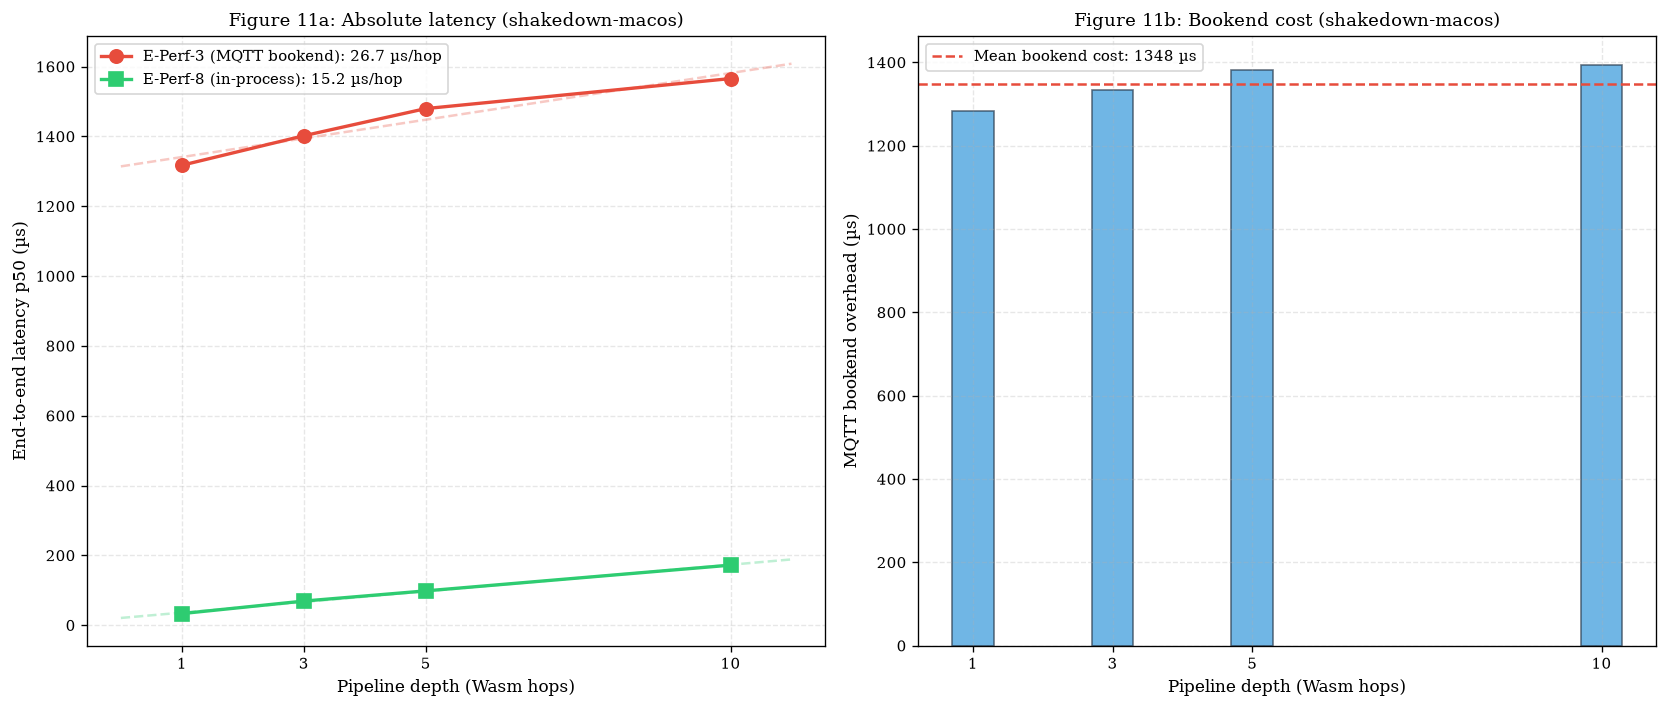

saved thesis figure to ../figures/e-perf-8/depth_scaling.pdf


<Figure size 720x480 with 0 Axes>

In [7]:
# Dual-line plot: E-Perf-3 vs E-Perf-8 p50
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: absolute latency (note different y-scales)
ax1.plot(DEPTHS, y3, 'o-', color='#e74c3c', linewidth=2, markersize=8,
         label=f'E-Perf-3 (MQTT bookend): {slope3:.1f} µs/hop')
ax1.plot(DEPTHS, y8, 's-', color='#2ecc71', linewidth=2, markersize=8,
         label=f'E-Perf-8 (in-process): {slope8:.1f} µs/hop')

# Linear fit lines
x_fit = np.linspace(0, 11, 50)
ax1.plot(x_fit, slope3*x_fit + intercept3, '--', color='#e74c3c', alpha=0.3)
ax1.plot(x_fit, slope8*x_fit + intercept8, '--', color='#2ecc71', alpha=0.3)

ax1.set_xlabel('Pipeline depth (Wasm hops)')
ax1.set_ylabel('End-to-end latency p50 (µs)')
ax1.set_title('Figure 11a: Absolute latency (shakedown-macos)')
ax1.set_xticks(DEPTHS)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right panel: bookend cost isolation
bookend_vals = [e3_medians[d] - e8_p50[d] for d in DEPTHS]
ax2.bar(DEPTHS, bookend_vals, width=0.6, color='#3498db', alpha=0.7,
        edgecolor='#2c3e50')
ax2.axhline(np.mean(bookend_vals), color='#e74c3c', linestyle='--',
            label=f'Mean bookend cost: {np.mean(bookend_vals):.0f} µs')
ax2.set_xlabel('Pipeline depth (Wasm hops)')
ax2.set_ylabel('MQTT bookend overhead (µs)')
ax2.set_title('Figure 11b: Bookend cost (shakedown-macos)')
ax2.set_xticks(DEPTHS)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
# T9: persist thesis figure to ../figures/e-perf-8/depth_scaling.{pdf,png}
_saved = save_figure(plt.gcf(), 'e-perf-8/depth_scaling')
print(f'saved thesis figure to {_saved}')


## Interpretation

The MQTT bookend cost (~1.3 ms on macOS) is dominated by the MQTT
source-to-broker and broker-to-sink round-trips. The per-hop slope
difference (~11 µs/hop) represents MQTT serialization overhead that
accumulates per hop (payload re-serialized through rumqttc at each
boundary).

For the thesis evaluation, this decomposition allows us to:
1. Report E-Perf-8 numbers as the pure Wasm pipeline overhead.
2. Report E-Perf-3 numbers as the system-level E2E latency.
3. Attribute the difference to the MQTT I/O layer, not the Wasm runtime.